## This script is to convert recorded demonstrations (from rosbag format) to samples (in txt format) to conform with the TP-GMM code.

In [1]:
import rosbag
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from sys import platform

# from franka_msgs.msg import FrankaState

print(platform)
if platform == "linux":
    main_dir = "/home/zizo/Data_dir/panda_sim_demons/batch7_RRT_rightside/"
    TPGMM_dir = "/home/zizo/tpgmm_rrt_ws/src/batteryDis-LfD/tp_gmm/data/"
elif platform == "win32":
    main_dir = "C:/Users/AWasf/OneDrive/Desktop/PhD Lab Work/Disassembly-Teleop/"
    TPGMM_dir = "C:/Users/AWasf/OneDrive/Desktop/PhD Lab Work/tp_gmm/data/"


linux


### Defining the directory according to the given task_name, and thus loop over the Demons in the directory (task_name, nbDemons in dir, ref_demon)

In [2]:
# Getting the task_name from tp-gmm.py
import pickle

with open('/home/zizo/tpgmm_rrt_ws/src/batteryDis-LfD/tp_gmm/scripts/demons_info1.pkl', 'rb') as fp:
    demons_info = pickle.load(fp)
    print(demons_info)
task_name = demons_info['task_name']
print("task_name: ", task_name)

# 
import os

demons_names = []
demons_nums = []
for filename in os.listdir(main_dir):
    ## filter out only files
    full_path = os.path.join(main_dir, filename)
    if os.path.isfile(full_path):
    ##\ filter out only files
        demons_names.append(filename)
        demons_nums.append(filename[filename.find('demon'):filename.find('.bag')])

print(demons_names)
print(demons_nums)

nbdemons = len(demons_names)
print("Number of Demons: ", nbdemons)


{'task_name': 'Rbolts'}
task_name:  Rbolts
['demon_7.bag', 'demon_2.bag', 'demon_5.bag', 'demon_4.bag', 'demon_11.bag', 'demon_12.bag', 'demon_1.bag', 'demon_14.bag', 'demon_9.bag', 'demon_10.bag', 'demon_15.bag', 'demon_6.bag', 'demon_8.bag', 'demon_13.bag', 'demon_3.bag']
['demon_7', 'demon_2', 'demon_5', 'demon_4', 'demon_11', 'demon_12', 'demon_1', 'demon_14', 'demon_9', 'demon_10', 'demon_15', 'demon_6', 'demon_8', 'demon_13', 'demon_3']
Number of Demons:  15


### 3D

In [3]:
from geometry_msgs.msg import Pose, PoseArray
from copy import deepcopy
from scipy.spatial.transform import Rotation as R


# ref_demon = {'ref':'', 'ref_nbpoints': 100000, 'nbDemons': nbdemons, 'demons_nums': demons_nums} # Choosing the shortest demon to be the reference in DTW
ref_demon = {'ref':'', 'ref_nbpoints': 0, 'nbDemons': nbdemons, 'demons_nums': demons_nums} # Choosing the longest demon to be the reference in DTW

# nb_obstacles = 2

for d in range(nbdemons): #

    demon_bag = rosbag.Bag(main_dir + demons_names[d], 'r')

    posearray_topic = "/gmm/learned_trajectory"
    start_pose_topic = "/start_pose"
    goal_pose_topic = "/goal_pose"
    obstacles_pose_topic = "/obstacles"
    
    ## Frames variables. NOTE: index 0 and 1 are always for start and goal frames. Starting from index 2, is the obstacles frames
    arr_frames_b = []
    arr_frames_A = []

    tp_count = 0 # Task-Parameters counter
    for topic, msg, t in demon_bag.read_messages(topics=[start_pose_topic, goal_pose_topic]): #, obstacles_pose_topic]):
        # print(topic)

        pos = [msg.pose.position.x, msg.pose.position.y, msg.pose.position.z]
        orient = R.from_quat([msg.pose.orientation.x, msg.pose.orientation.y, msg.pose.orientation.z, msg.pose.orientation.w])
        # print(orient.as_quat())
        # print(orient.as_euler('ZYX'))
        # print(orient.as_matrix())

        arr_frames_b.append(np.array([[0], [pos[0]], [pos[1]], [pos[2]]]))
        arr_frames_A.append(np.eye(4))
        arr_frames_A[-1][1:,1:] = orient.as_matrix()       
        # print(arr_frame1_A)  

        # print("st_orient \n ", orient.as_quat())

        tp_count += 1

    for topic, msg, t in demon_bag.read_messages(topics=[obstacles_pose_topic]):
        for obstacle in msg.poses:
            pos = [obstacle.position.x, obstacle.position.y, obstacle.position.z]
            orient = R.from_quat([obstacle.orientation.x, obstacle.orientation.y, obstacle.orientation.z, obstacle.orientation.w])

            arr_frames_b.append(np.array([[0], [pos[0]], [pos[1]], [pos[2]]]))
            arr_frames_A.append(np.eye(4))
            arr_frames_A[-1][1:,1:] = orient.as_matrix()

            # print("ob_orient \n ", orient.as_quat())

            tp_count += 1


    nb_tp = tp_count # Number of Task-Parameters, including start, goal, and obstacles' poses
    print("nb_tp = ", nb_tp)
    dim = 1 + 3
    conc_arr_Data = np.zeros((dim,1))
    down_sample = 1 # 30
    # msg_count = 0
    for topic, msg, t in demon_bag.read_messages(topics=[posearray_topic]):
        for pose_count, pose in enumerate(msg.poses):

            # Preparing the Data points matrix from the Demons
            arr_Data = np.array([[pose_count], [pose.position.x], [pose.position.y], [pose.position.z]]) # time sample

            conc_arr_Data = np.concatenate((conc_arr_Data, arr_Data), axis=1)

    # if demons_nums[d] == "demon_27":
    #     print("Ref demon data points: ",  conc_arr_Data.shape)
    #     print(conc_arr_Data[:,12])
    #     print(pose_count)
    # #\ debugging
    
    demon_bag.close()
    
    print("Number of data points in {}: {}".format(demons_nums[d], conc_arr_Data.shape[1]-1)) #, msg_count)
    
    # ## Choosing the shortest Demon to be the reference Demon
    # ## if (msg_count < ref_demon['ref_nbpoints']):
    # ##     ref_demon["ref"] = demons_nums[d]
    # ##     ref_demon["ref_nbpoints"] = msg_count
    # if (conc_arr_Data.shape[1]-1 < ref_demon['ref_nbpoints']):
    #     ref_demon["ref"] = demons_nums[d]
    #     ref_demon["ref_nbpoints"] = conc_arr_Data.shape[1]-1 # because the DTW reduces 1 point!! # msg_count
    #     ref_demon["down_sample_factor"] = down_sample  
    # ##\ Choosing the shortest Demon to be the reference Demon

    ## Choosing the longest Demon to be the reference Demon
    # if (msg_count > ref_demon['ref_nbpoints']):
    if (conc_arr_Data.shape[1]-1 > ref_demon['ref_nbpoints']):
        ref_demon["ref"] = demons_nums[d]
        ref_demon["ref_nbpoints"] = conc_arr_Data.shape[1]-1 # because the DTW reduces 1 point!! # msg_count
        ref_demon["down_sample_factor"] = down_sample  
    ##\ Choosing the longest Demon to be the reference Demon


    # # Filling in b matrix & A matrix for all frames
    print("len(arr_frames_b) = ", len(arr_frames_b))
    for frame in range(nb_tp):
        conc_arr_frame_b = np.ones((dim, pose_count)) * arr_frames_b[frame]
        conc_arr_frame_A = np.tile(arr_frames_A[frame], pose_count) 

        # Saving in txt files
        np.savetxt(TPGMM_dir + demons_nums[d] + "_sample_Data.txt", conc_arr_Data[:,1:], fmt='%.5f') # cut out the 1st column (zeros) that was created only to initialize the array 

        np.savetxt(TPGMM_dir + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), conc_arr_frame_b, fmt='%.5f')
        np.savetxt(TPGMM_dir + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), conc_arr_frame_A, fmt='%.5f')


        # Add the ',' to put file in the format that TP-GMM code accepts
        with open(r"{}".format(TPGMM_dir) + demons_nums[d]+ "_sample_Data.txt", 'r') as f: # The 'r' before the directory name is to open the file as read-only
            data = f.read(); data = data.replace(' ', ',')
        with open(r"{}".format(TPGMM_dir) + demons_nums[d]+ "_sample_Data.txt", 'w') as f:
            f.write(data)
            
        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), 'r') as f:
            data = f.read(); data = data.replace(' ', ',')
        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), 'w') as f:
            f.write(data)

        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), 'r') as f:
            data = f.read(); data = data.replace(' ', ',')
        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), 'w') as f:
            f.write(data)

print("Reference Demon:")
print(ref_demon)
with open('/home/zizo/tpgmm_rrt_ws/src/batteryDis-LfD/tp_gmm/scripts/demons_info2.pkl', 'wb') as fp:
    pickle.dump(ref_demon, fp)

nb_tp =  3
Number of data points in demon_7: 58
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_2: 43
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_5: 43
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_4: 57
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_11: 36
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_12: 57
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_1: 68
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_14: 53
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_9: 123
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_10: 54
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_15: 48
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_6: 72
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_8: 64
len(arr_frames_b) =  3
nb_tp =  3
Number of data points in demon_13: 66
len(arr_frames_b) =  3

### DTW the demons

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.

Reference Demon:
(4, 123)
DTWinng..
(4, 58)
(122,)
972.7017543859649
44.478470415443915
0.24573740561018736
nb_tp =  3
Debugging
(4, 122)


DTWinng..
(4, 43)
(122,)
737.9999999999999
28.813414470364474
0.17357478596605105
nb_tp =  3
Debugging
(4, 122)


DTWinng..
(4, 43)
(122,)
1239.5714285714284
38.84955601574598
0.23403346997437338
nb_tp =  3
Debugging
(4, 122)


DTWinng..
(4, 57)
(122,)
625.6428571428571
27.77309531973681
0.15429497399853784
nb_tp =  3
Debugging
(4, 122)


DTWinng..
(4, 36)
(122,)
500.42857142857144
31.130010243012656
0.19578622794347583
nb_tp =  3
Debugging
(4, 122)


DTWinng..
(4, 57)
(122,)
653.2142857142856
41.18123185324963
0.2287846214069424
nb_tp =  3
Debugging
(4, 122)


DTWinng..
(4, 68)
(122,)
2108.0
63.41561246963576
0.33201891345359036
nb_tp =  3
D

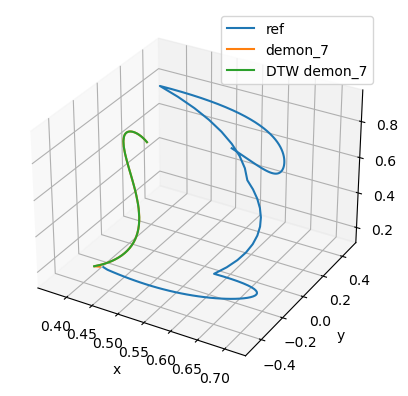

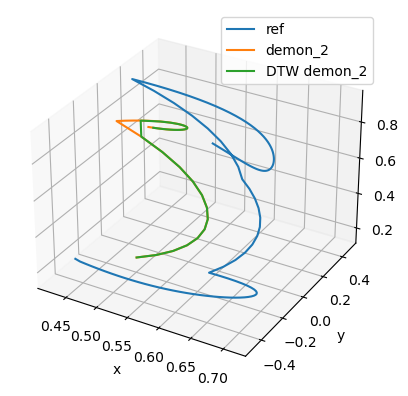

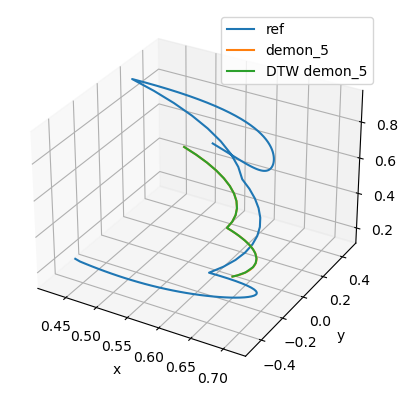

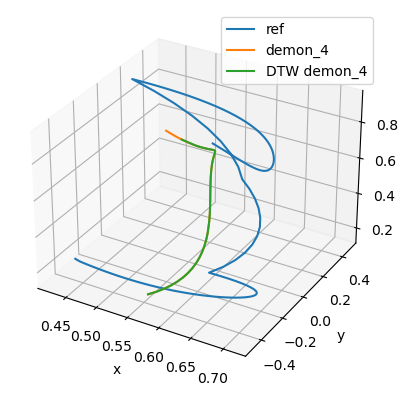

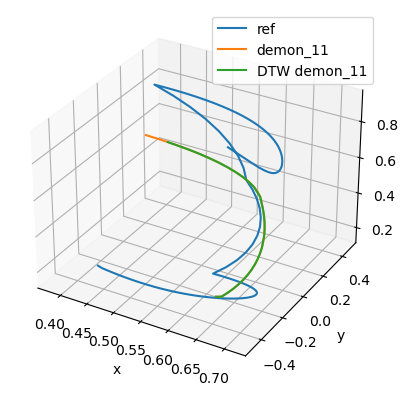

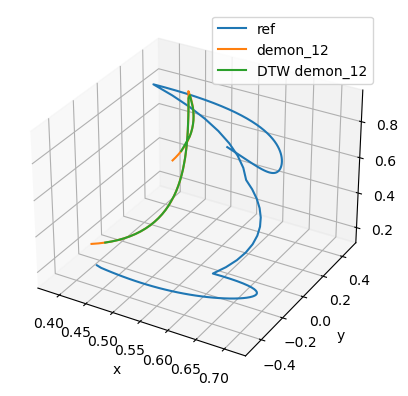

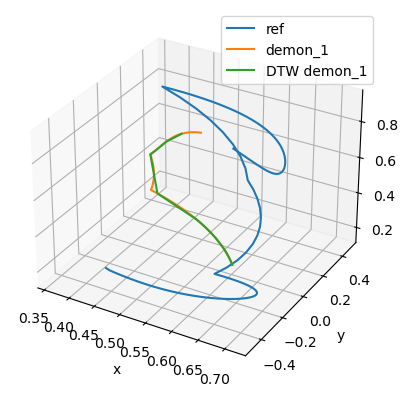

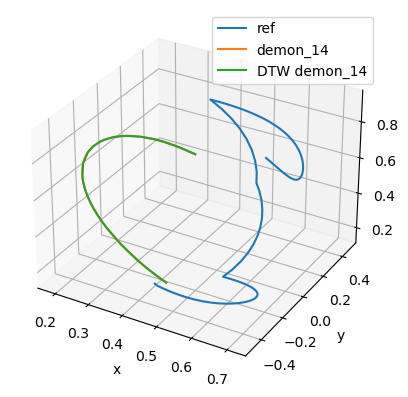

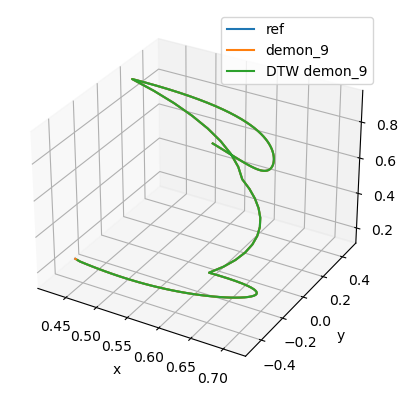

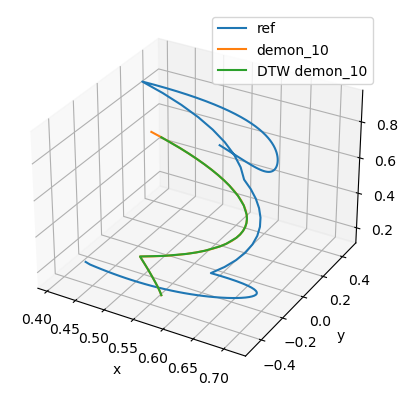

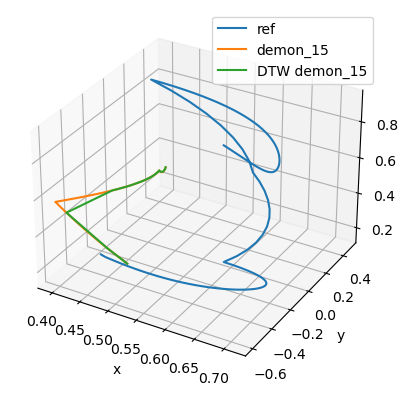

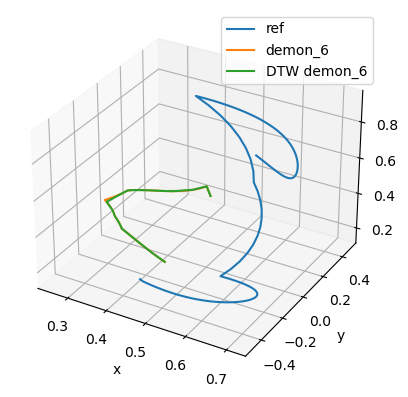

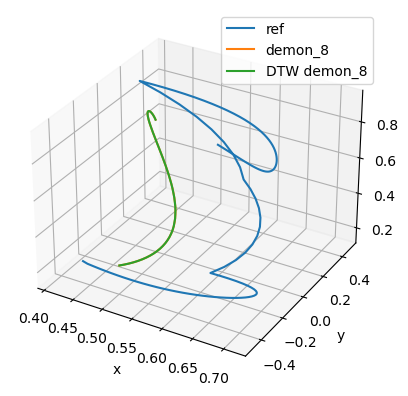

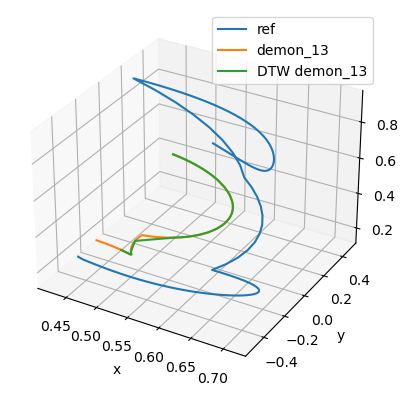

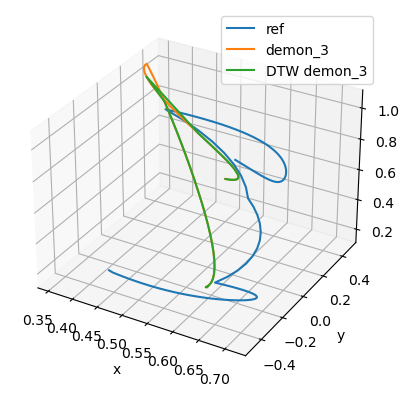

In [4]:
%matplotlib inline
# %matplotlib qt
from dtw import *

print("Reference Demon:")
ref_arr_Data = np.loadtxt(TPGMM_dir + ref_demon['ref'] + "_sample_Data.txt", delimiter=',')
print(ref_arr_Data.shape)
demons_nums_dtw = []

for d in range(nbdemons):
    
    print("DTWinng..")
    temp_arr_Data = np.loadtxt(TPGMM_dir + demons_nums[d] + "_sample_Data.txt", delimiter=',')
    print(temp_arr_Data.shape)

    DTW = dtw(temp_arr_Data[1:,:].T, ref_arr_Data[1:,:].T)
    wq = warp(DTW, index_reference=False)
    print(wq.shape)
    print(warpArea(DTW))
    print(DTW.distance)
    print(DTW.normalizedDistance)

    # if (DTW.normalizedDistance >= 0.30): continue # Filter out the odd demons
    
    ## Plotting
    fig = plt.figure()
    ax = plt.axes(projection='3d')

    ax.plot(ref_arr_Data[1,:], ref_arr_Data[2,:], ref_arr_Data[3,:], label='ref')
    ax.plot(temp_arr_Data[1,:], temp_arr_Data[2,:], temp_arr_Data[3,:], label='{}'.format(demons_nums[d]))
    ax.plot(temp_arr_Data[1,wq], temp_arr_Data[2,wq], temp_arr_Data[3,wq], label='DTW {}'.format(demons_nums[d]))
    
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    ## Saving in .txt
    temp_arr_Data = temp_arr_Data[:,wq]
    # print("temp_arr_Data: ", temp_arr_Data.shape)
    # print("ref_arr_Data: ", ref_arr_Data.shape)
    temp_arr_Data[0,:] = ref_arr_Data[0,:ref_arr_Data.shape[1]-1] # NOTE: It seems that with the update of 'dtw' package, this '-1' here has to be removed # UPDATE: -1 has to be there

    np.savetxt(TPGMM_dir + demons_nums[d] + "_sample_Data.txt", temp_arr_Data, fmt='%.5f')
    with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_Data.txt", 'r') as f: # The 'r' before the directory name is to open the file as read-only
        data = f.read(); data = data.replace(' ', ',')
    with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_Data.txt", 'w') as f:
        f.write(data)
    
    print("nb_tp = ", nb_tp)
    for frame in range(nb_tp):  
        # Re-shaping the A & b matrices .txt to be of the same shape as the reference Demon (longest or shortest)
        temp_arr_frame_b = np.loadtxt(TPGMM_dir + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), delimiter=',')
        temp_arr_frame_A = np.loadtxt(TPGMM_dir + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), delimiter=',')

        temp_arr_frame_b = np.ones((ref_arr_Data.shape[0], ref_arr_Data.shape[1])) * temp_arr_frame_b[:,0].reshape(ref_arr_Data.shape[0], 1)
        temp_arr_frame_A = np.tile(temp_arr_frame_A[:4,:4], ref_arr_Data.shape[1])

        np.savetxt(TPGMM_dir + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), temp_arr_frame_b, fmt='%.5f')
        np.savetxt(TPGMM_dir + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), temp_arr_frame_A, fmt='%.5f')


        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), 'r') as f:
            data = f.read(); data = data.replace(' ', ',')
        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_b.txt".format(frame+1), 'w') as f:
            f.write(data)

        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), 'r') as f:
            data = f.read(); data = data.replace(' ', ',')
        with open(r"{}".format(TPGMM_dir) + demons_nums[d] + "_sample_frame{}_A.txt".format(frame+1), 'w') as f:
            f.write(data)


    ## Only for debuggin to check the txt file shape
    print("Debugging")
    temp_arr_Data = np.loadtxt(TPGMM_dir + demons_nums[d] + "_sample_Data.txt", delimiter=',')
    print(temp_arr_Data.shape)
    print("\n")

    demons_nums_dtw.append(demons_nums[d])
    
# Resend the dictionary again after filtering the Demons according to DTW (i.e. keeping the most similar ones)
ref_demon["demons_nums"] = demons_nums_dtw
ref_demon["nbDemons"] = len(ref_demon["demons_nums"])
print("Reference Demon:")
print(ref_demon)
with open('/home/zizo/tpgmm_rrt_ws/src/batteryDis-LfD/tp_gmm/scripts/demons_info2.pkl', 'wb') as fp:
    pickle.dump(ref_demon, fp)    


In [5]:
# print(temp_arr_frame1_b.shape)
# print(temp_arr_frame1_A.shape)
# print(temp_arr_frame2_b.shape)
# print(temp_arr_frame2_A.shape)
# print(temp_arr_frame2_A[:4,:4].shape)